# YOLOv8n 튜닝 모델 - Threshold 최적화
- **파일명**: `11-1_threshold_optimization_tuned.ipynb`
- **저장 경로**: `N:\개인\이수빈\3.13_Mini_Project\scripts\`
- **목적**: 튜닝 모델의 최적 Confidence Threshold 탐색
- **작성일**: 2026-03-04

### 왜 하는가?
- 모델이 바뀌면 최적 Threshold도 달라짐
- 현재 Threshold 0.20에서 KPI 달성 상태 (Recall 0.922, Precision 0.945)
- Precision 여유분(+6.5%p)을 활용해 Recall을 더 올릴 수 있는지 확인

### 테스트할 Threshold
- 0.05, 0.10, 0.15, 0.20, 0.25 (5단계)


## 셀 1: 라이브러리 import


In [1]:
# =============================================================================
# [셀 1] 라이브러리 임포트
# =============================================================================

# YOLO 모델 추론용
from ultralytics import YOLO

# 경로 처리
from pathlib import Path

# 표 형태 데이터 처리
import pandas as pd

# JSON 저장
import json

# 날짜/시간 기록
from datetime import datetime

# 그래프 시각화
import matplotlib.pyplot as plt

# 한글 폰트 설정 (그래프에서 한글 깨짐 방지)
plt.rcParams['font.family'] = 'Malgun Gothic'   # Windows 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False       # 마이너스 기호 깨짐 방지

print("✅ 라이브러리 import 완료")


✅ 라이브러리 import 완료


## 셀 2: 경로 설정


In [2]:
# =============================================================================
# [셀 2] 프로젝트 경로 설정
# =============================================================================

# 프로젝트 최상위 폴더 경로
PROJECT_ROOT = Path(r'N:\개인\이수빈\3.13_Mini_Project')

# 튜닝된 모델 가중치 파일 경로
MODEL_PATH = PROJECT_ROOT / 'results' / 'yolov8n_tuned' / 'weights' / 'best.pt'

# 테스트 이미지 폴더 경로
TEST_DIR = PROJECT_ROOT / 'DATASET' / 'test_set_894'

# 결과 저장 폴더
EVAL_DIR = PROJECT_ROOT / 'evaluation' / 'yolov8n_tuned_threshold'
EVAL_DIR.mkdir(parents=True, exist_ok=True)

# 테스트할 Threshold 목록 (5단계)
THRESHOLDS = [0.05, 0.10, 0.15, 0.20, 0.25]

# KPI 목표값 (그래프에 기준선으로 표시할 용도)
KPI_RECALL = 0.920
KPI_PRECISION = 0.880

print(f"모델: {MODEL_PATH}")
print(f"테스트 폴더: {TEST_DIR}")
print(f"결과 저장: {EVAL_DIR}")
print(f"테스트 Threshold: {THRESHOLDS}")


모델: N:\개인\이수빈\3.13_Mini_Project\results\yolov8n_tuned\weights\best.pt
테스트 폴더: N:\개인\이수빈\3.13_Mini_Project\DATASET\test_set_894
결과 저장: N:\개인\이수빈\3.13_Mini_Project\evaluation\yolov8n_tuned_threshold
테스트 Threshold: [0.05, 0.1, 0.15, 0.2, 0.25]


## 셀 3: TDD 테스트 함수 정의


In [3]:
# =============================================================================
# [셀 3] TDD - 테스트 함수 정의
# =============================================================================

def test_model_loaded(model):
    """테스트 1: 모델 정상 로드 확인"""
    assert model is not None, "모델 로드 실패!"
    print("✅ 테스트 1 통과: 모델 정상 로드됨")

def test_images_count(fire_imgs, normal_imgs):
    """테스트 2: 이미지 수 확인"""
    assert len(fire_imgs) > 0, "화재 이미지 없음!"
    assert len(normal_imgs) > 0, "정상 이미지 없음!"
    total = len(fire_imgs) + len(normal_imgs)
    print(f"✅ 테스트 2 통과: 화재 {len(fire_imgs)}장, 정상 {len(normal_imgs)}장, 총 {total}장")

def test_results_valid(results_list):
    """테스트 3: 모든 Threshold 결과가 유효한지 확인"""
    for r in results_list:
        assert 0 <= r['recall'] <= 1, f"Recall 범위 초과: {r['recall']}"
        assert 0 <= r['precision'] <= 1, f"Precision 범위 초과: {r['precision']}"
        # Threshold가 낮을수록 Recall이 높아야 함 (일반적 경향)
    print(f"✅ 테스트 3 통과: {len(results_list)}개 Threshold 결과 모두 유효")


## 셀 4: 모델 로드 및 이미지 수집


In [4]:
# =============================================================================
# [셀 4] 모델 로드 + 이미지 수집
# =============================================================================

# 모델 로드
model = YOLO(str(MODEL_PATH))
test_model_loaded(model)

# 화재 이미지 수집 (set으로 중복 제거)
fire_paths = set()
for ext in ['*.jpg', '*.jpeg', '*.png', '*.webp',
            '*.JPG', '*.JPEG', '*.PNG', '*.WEBP']:
    for p in (TEST_DIR / 'fire').glob(ext):
        fire_paths.add(p)

# 정상 이미지 수집 (폴더명: normal)
normal_paths = set()
for ext in ['*.jpg', '*.jpeg', '*.png', '*.webp',
            '*.JPG', '*.JPEG', '*.PNG', '*.WEBP']:
    for p in (TEST_DIR / 'normal').glob(ext):
        normal_paths.add(p)

# 정렬된 리스트로 변환
test_fire = sorted(list(fire_paths))
test_normal = sorted(list(normal_paths))

# 테스트 2 실행
test_images_count(test_fire, test_normal)


✅ 테스트 1 통과: 모델 정상 로드됨
✅ 테스트 2 통과: 화재 447장, 정상 447장, 총 894장


## 셀 5: 평가 함수 정의
- `model.predict(conf=threshold)` 방식 사용
- 각 Threshold별로 TP, FN, FP, TN을 세어 Recall/Precision/F1 계산


In [5]:
# =============================================================================
# [셀 5] 단일 Threshold 평가 함수 정의
# =============================================================================

def evaluate_at_threshold(model, fire_images, normal_images, threshold):
    """
    특정 Threshold에서 모델 성능을 평가하는 함수
    
    쉽게 말하면:
    - 모든 화재/정상 이미지를 하나씩 모델에 보여줌
    - 해당 threshold 기준으로 화재 여부를 판정
    - TP/FN/FP/TN을 세고 Recall/Precision/F1을 계산
    
    매개변수:
        model: YOLO 모델
        fire_images: 화재 이미지 경로 리스트
        normal_images: 정상 이미지 경로 리스트
        threshold: Confidence threshold (예: 0.10)
    
    반환값:
        딕셔너리: threshold, TP, FN, FP, TN, recall, precision, f1
    """
    # 화재 이미지 평가 → TP(탐지) / FN(미탐) 카운트
    tp = 0  # True Positive: 화재를 화재로 맞춤
    fn = 0  # False Negative: 화재를 놓침 (미탐)
    
    for img_path in fire_images:
        # model.predict에 conf를 직접 전달 → YOLO 내부에서 필터링
        results = model.predict(
            str(img_path),       # 이미지 경로
            conf=threshold,      # ★ 핵심: threshold를 YOLO에 전달
            imgsz=640,           # 이미지 크기
            save=False,          # 자동 저장 안 함
            verbose=False        # 로그 최소화
        )
        # bbox가 1개 이상 있으면 → 화재 탐지 성공
        if len(results[0].boxes) > 0:
            tp += 1
        else:
            fn += 1
    
    # 정상 이미지 평가 → FP(오탐) / TN(정탐) 카운트
    fp = 0  # False Positive: 정상을 화재로 오인 (오탐)
    tn = 0  # True Negative: 정상을 정상으로 맞춤
    
    for img_path in normal_images:
        results = model.predict(
            str(img_path),
            conf=threshold,
            imgsz=640,
            save=False,
            verbose=False
        )
        if len(results[0].boxes) > 0:
            fp += 1
        else:
            tn += 1
    
    # 성능 지표 계산
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'threshold': threshold,
        'tp': tp, 'fn': fn, 'fp': fp, 'tn': tn,
        'recall': round(recall, 4),
        'precision': round(precision, 4),
        'f1': round(f1, 4)
    }


## 셀 6: 5개 Threshold 평가 실행
- ⚠️ 약 5~10분 소요 (Threshold 5개 × 894장)


In [6]:
# =============================================================================
# [셀 6] 5개 Threshold 전체 평가 실행
# ⚠️ 약 5~10분 소요
# =============================================================================

print("🚀 Threshold 최적화 시작!")
print(f"시작: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"테스트할 Threshold: {THRESHOLDS}")
print(f"이미지: 화재 {len(test_fire)}장 + 정상 {len(test_normal)}장")
print("=" * 60)

# 결과를 담을 리스트
all_results = []

# 각 Threshold별로 평가 실행
for th in THRESHOLDS:
    print(f"\n📊 Threshold {th} 평가 중...")
    start = datetime.now()
    
    # 평가 실행
    result = evaluate_at_threshold(model, test_fire, test_normal, th)
    
    # 소요 시간 계산
    elapsed = (datetime.now() - start).total_seconds()
    
    # 결과 리스트에 추가
    all_results.append(result)
    
    # 중간 결과 출력
    print(f"  Recall: {result['recall']:.3f}  Precision: {result['precision']:.3f}  "
          f"F1: {result['f1']:.3f}  미탐: {result['fn']}  오탐: {result['fp']}  "
          f"({elapsed:.0f}초)")

# 테스트 3 실행: 결과 유효성 확인
test_results_valid(all_results)

print(f"\n✅ 전체 평가 완료: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 60)


🚀 Threshold 최적화 시작!
시작: 2026-03-04 12:01:31
테스트할 Threshold: [0.05, 0.1, 0.15, 0.2, 0.25]
이미지: 화재 447장 + 정상 447장

📊 Threshold 0.05 평가 중...
  Recall: 0.989  Precision: 0.877  F1: 0.929  미탐: 5  오탐: 62  (109초)

📊 Threshold 0.1 평가 중...
  Recall: 0.980  Precision: 0.932  F1: 0.955  미탐: 9  오탐: 32  (118초)

📊 Threshold 0.15 평가 중...
  Recall: 0.958  Precision: 0.941  F1: 0.949  미탐: 19  오탐: 27  (116초)

📊 Threshold 0.2 평가 중...
  Recall: 0.922  Precision: 0.945  F1: 0.933  미탐: 35  오탐: 24  (117초)

📊 Threshold 0.25 평가 중...
  Recall: 0.897  Precision: 0.959  F1: 0.927  미탐: 46  오탐: 17  (112초)
✅ 테스트 3 통과: 5개 Threshold 결과 모두 유효

✅ 전체 평가 완료: 2026-03-04 12:11:02


## 셀 7: Threshold별 비교표


In [7]:
# =============================================================================
# [셀 7] Threshold별 비교표 출력
# =============================================================================

# 결과를 DataFrame으로 변환 (표 형태로 보기 좋게)
df = pd.DataFrame(all_results)

print("\n" + "=" * 70)
print("📊 YOLOv8n Tuned - Threshold별 성능 비교")
print("=" * 70)
print(f"{'Threshold':>10} {'Recall':>8} {'Precision':>10} {'F1':>8} {'미탐':>6} {'오탐':>6}")
print("-" * 50)

for _, row in df.iterrows():
    # KPI 달성 여부 표시
    r_mark = "✅" if row['recall'] >= KPI_RECALL else "❌"
    p_mark = "✅" if row['precision'] >= KPI_PRECISION else "❌"
    
    print(f"{row['threshold']:>10.2f} "
          f"{row['recall']:>7.3f}{r_mark} "
          f"{row['precision']:>9.3f}{p_mark} "
          f"{row['f1']:>7.3f} "
          f"{row['fn']:>5} "
          f"{row['fp']:>5}")

print("-" * 50)
print(f"KPI 목표:    Recall >= {KPI_RECALL}   Precision >= {KPI_PRECISION}")
print("=" * 70)

# ── KPI 둘 다 달성한 Threshold 찾기 ──
kpi_pass = df[(df['recall'] >= KPI_RECALL) & (df['precision'] >= KPI_PRECISION)]

if len(kpi_pass) > 0:
    # F1이 가장 높은 것을 최적으로 선정
    best = kpi_pass.loc[kpi_pass['f1'].idxmax()]
    print(f"\n⭐ 최적 Threshold: {best['threshold']:.2f}")
    print(f"   Recall: {best['recall']:.3f}  Precision: {best['precision']:.3f}  F1: {best['f1']:.3f}")
    print(f"   미탐: {int(best['fn'])}건  오탐: {int(best['fp'])}건")
else:
    print("\n⚠️ KPI를 둘 다 달성하는 Threshold가 없습니다.")
    # F1 기준 최고를 대안으로 제시
    best = df.loc[df['f1'].idxmax()]
    print(f"   F1 최고 Threshold: {best['threshold']:.2f} (Recall: {best['recall']:.3f}, Precision: {best['precision']:.3f})")



📊 YOLOv8n Tuned - Threshold별 성능 비교
 Threshold   Recall  Precision       F1     미탐     오탐
--------------------------------------------------
      0.05   0.989✅     0.877❌   0.929   5.0  62.0
      0.10   0.980✅     0.932✅   0.955   9.0  32.0
      0.15   0.958✅     0.941✅   0.949  19.0  27.0
      0.20   0.922✅     0.945✅   0.933  35.0  24.0
      0.25   0.897❌     0.959✅   0.927  46.0  17.0
--------------------------------------------------
KPI 목표:    Recall >= 0.92   Precision >= 0.88

⭐ 최적 Threshold: 0.10
   Recall: 0.980  Precision: 0.932  F1: 0.955
   미탐: 9건  오탐: 32건


## 셀 8: 시각화 — Recall / Precision / F1 그래프
- Threshold에 따른 성능 변화를 한눈에 확인
- KPI 목표선 표시


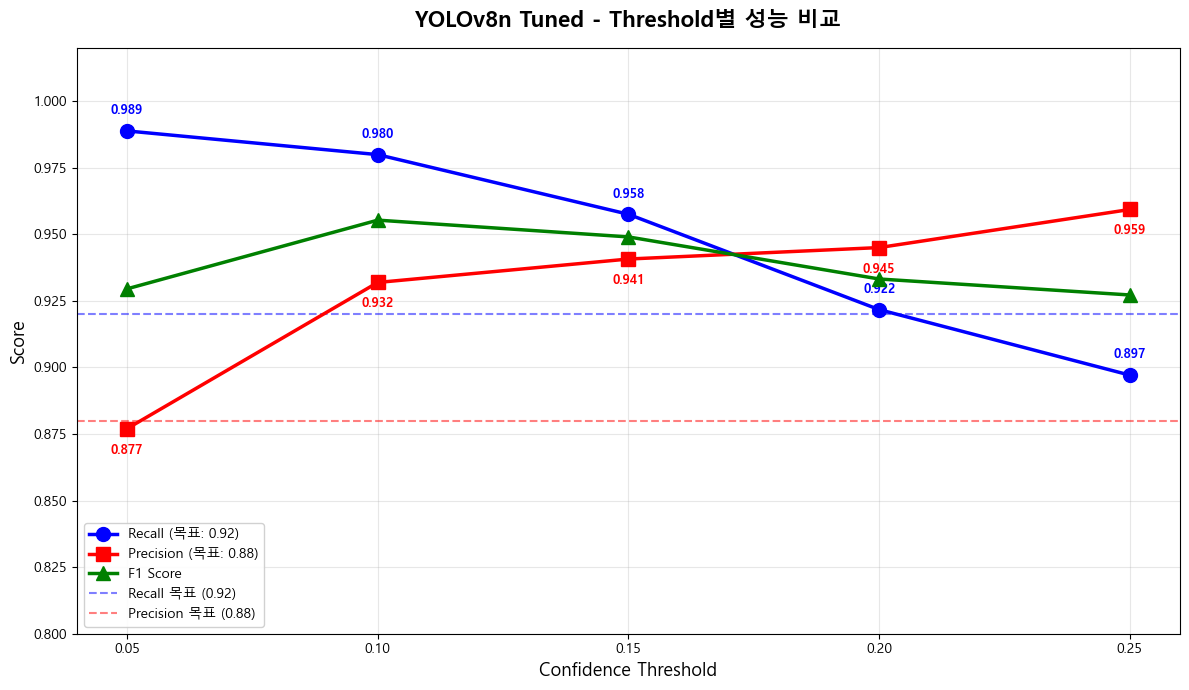

💾 그래프 저장: N:\개인\이수빈\3.13_Mini_Project\evaluation\yolov8n_tuned_threshold\threshold_recall_precision_f1.png


In [8]:
# =============================================================================
# [셀 8] 시각화 1: Threshold별 Recall / Precision / F1 그래프
# =============================================================================

# 그래프 크기 설정 (가로 12, 세로 7 인치)
fig, ax = plt.subplots(figsize=(12, 7))

# Threshold 값 리스트 (x축)
thresholds = df['threshold'].tolist()

# Recall 꺾은선 (파란색, 원형 마커)
ax.plot(thresholds, df['recall'], 'b-o', linewidth=2.5, markersize=10,
        label=f'Recall (목표: {KPI_RECALL})', zorder=5)

# Precision 꺾은선 (빨간색, 사각 마커)
ax.plot(thresholds, df['precision'], 'r-s', linewidth=2.5, markersize=10,
        label=f'Precision (목표: {KPI_PRECISION})', zorder=5)

# F1 Score 꺾은선 (초록색, 삼각 마커)
ax.plot(thresholds, df['f1'], 'g-^', linewidth=2.5, markersize=10,
        label='F1 Score', zorder=5)

# KPI 목표선 (점선)
ax.axhline(y=KPI_RECALL, color='blue', linestyle='--', alpha=0.5,
           label=f'Recall 목표 ({KPI_RECALL})')
ax.axhline(y=KPI_PRECISION, color='red', linestyle='--', alpha=0.5,
           label=f'Precision 목표 ({KPI_PRECISION})')

# 각 포인트에 수치 표시
for i, row in df.iterrows():
    # Recall 수치
    ax.annotate(f"{row['recall']:.3f}",
                (row['threshold'], row['recall']),
                textcoords="offset points", xytext=(0, 12),
                ha='center', fontsize=9, color='blue', fontweight='bold')
    # Precision 수치
    ax.annotate(f"{row['precision']:.3f}",
                (row['threshold'], row['precision']),
                textcoords="offset points", xytext=(0, -18),
                ha='center', fontsize=9, color='red', fontweight='bold')

# 그래프 제목 및 라벨
ax.set_title('YOLOv8n Tuned - Threshold별 성능 비교', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Confidence Threshold', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_xticks(thresholds)
ax.set_ylim(0.80, 1.02)
ax.legend(loc='lower left', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)

# 여백 조정 및 저장
plt.tight_layout()
chart_path1 = EVAL_DIR / 'threshold_recall_precision_f1.png'
plt.savefig(chart_path1, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 그래프 저장: {chart_path1}")


## 셀 9: 시각화 — 미탐(FN) / 오탐(FP) 건수 비교
- 미탐은 화재를 놓치는 것 → 생명 위험 (최소화 최우선)
- 오탐은 거짓 알람 → 불편하지만 안전에는 문제 없음


C:\Users\User\AppData\Local\Temp\ipykernel_14480\1990522582.py:44: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_14480\1990522582.py:44: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_14480\1990522582.py:46: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  plt.savefig(chart_path2, dpi=150, bbox_inches='tight')
C:\Users\User\AppData\Local\Temp\ipykernel_14480\1990522582.py:46: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  plt.savefig(chart_path2, dpi=150, bbox_inches='tight')
c:\Users\User\.conda\envs\DL\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\User\.conda\envs\DL\lib\site-pa

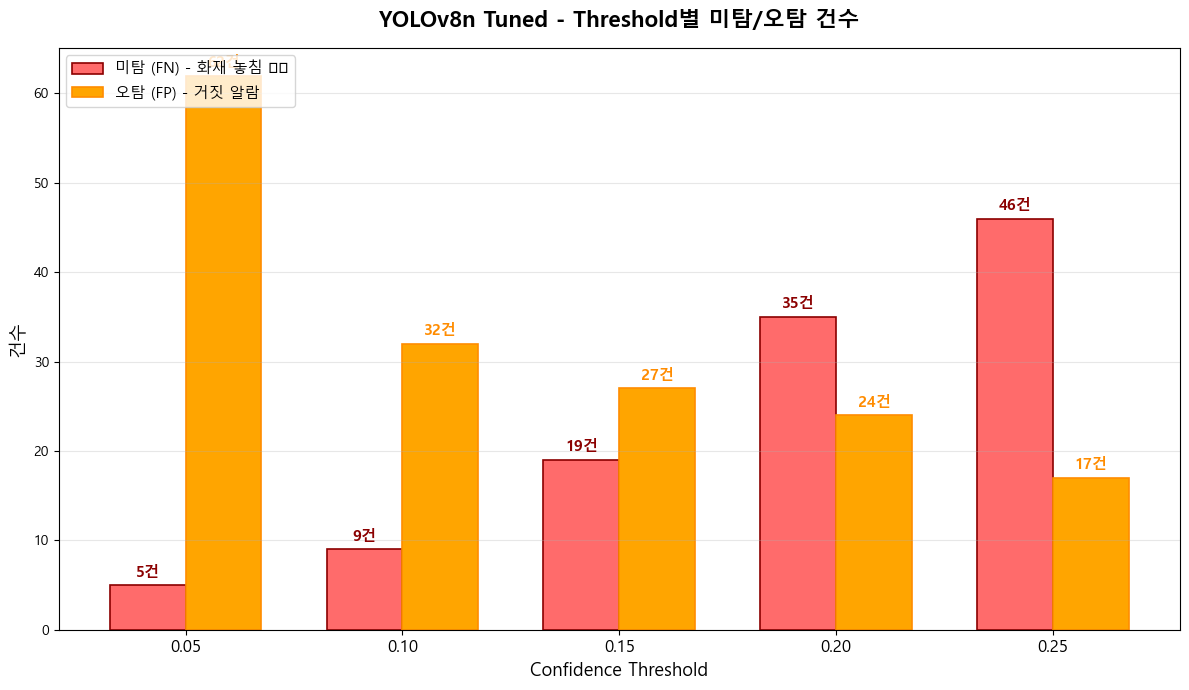

💾 그래프 저장: N:\개인\이수빈\3.13_Mini_Project\evaluation\yolov8n_tuned_threshold\threshold_fn_fp_comparison.png


In [9]:
# =============================================================================
# [셀 9] 시각화 2: Threshold별 미탐/오탐 건수 막대그래프
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 7))

# x축 위치 (막대 배치용)
x = range(len(thresholds))
width = 0.35  # 막대 너비

# 미탐(FN) 막대 — 빨간색 (위험!)
bars_fn = ax.bar([i - width/2 for i in x], df['fn'], width,
                  label='미탐 (FN) - 화재 놓침 ⚠️', color='#FF6B6B',
                  edgecolor='darkred', linewidth=1.2)

# 오탐(FP) 막대 — 주황색
bars_fp = ax.bar([i + width/2 for i in x], df['fp'], width,
                  label='오탐 (FP) - 거짓 알람', color='#FFA500',
                  edgecolor='darkorange', linewidth=1.2)

# 각 막대 위에 건수 표시
for bar in bars_fn:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{int(height)}건', ha='center', va='bottom',
            fontweight='bold', fontsize=11, color='darkred')

for bar in bars_fp:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{int(height)}건', ha='center', va='bottom',
            fontweight='bold', fontsize=11, color='darkorange')

# 그래프 설정
ax.set_title('YOLOv8n Tuned - Threshold별 미탐/오탐 건수', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Confidence Threshold', fontsize=13)
ax.set_ylabel('건수', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([f'{th:.2f}' for th in thresholds], fontsize=12)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, axis='y', alpha=0.3)

# 여백 조정 및 저장
plt.tight_layout()
chart_path2 = EVAL_DIR / 'threshold_fn_fp_comparison.png'
plt.savefig(chart_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 그래프 저장: {chart_path2}")


## 셀 10: Default 모델 vs 튜닝 모델 — 각자 최적 Threshold 기준 비교
- Default 모델: Threshold 0.10 기준 (이전에 이미 최적화 완료)
- 튜닝 모델: 이번에 찾은 최적 Threshold 기준


In [12]:
# =============================================================================
# [셀 10] Default vs Tuned 최종 비교
# =============================================================================

# Default 모델 최적 성능 (Threshold 0.10, 이전 평가 결과)
default_best = {
    'threshold': 0.10,
    'recall': 0.957,
    'precision': 0.937,
    'f1': 0.947,
    'fn': 19,
    'fp': 29
}

# 튜닝 모델에서 KPI 달성 + F1 최고인 Threshold 선정
kpi_pass = df[(df['recall'] >= KPI_RECALL) & (df['precision'] >= KPI_PRECISION)]
if len(kpi_pass) > 0:
    best_idx = kpi_pass['f1'].idxmax()
    tuned_best = kpi_pass.loc[best_idx].to_dict()
else:
    # KPI 미달성 시 F1 최고 선택
    best_idx = df['f1'].idxmax()
    tuned_best = df.loc[best_idx].to_dict()

print("\n" + "=" * 65)
print("📈 최종 비교: Default(최적) vs Tuned(최적)")
print("=" * 65)
tuned_th = tuned_best['threshold']
print(f"{'항목':<14} {'Default(th=0.10)':>18} {f'Tuned(th={tuned_th:.2f})':>18} {'차이':>10}")
print("-" * 62)
print(f"{'Recall':<14} {default_best['recall']:>18.3f} {tuned_best['recall']:>18.3f} {tuned_best['recall']-default_best['recall']:>+10.3f}")
print(f"{'Precision':<14} {default_best['precision']:>18.3f} {tuned_best['precision']:>18.3f} {tuned_best['precision']-default_best['precision']:>+10.3f}")
print(f"{'F1':<14} {default_best['f1']:>18.3f} {tuned_best['f1']:>18.3f} {tuned_best['f1']-default_best['f1']:>+10.3f}")
print(f"{'미탐(FN)':<14} {default_best['fn']:>18} {int(tuned_best['fn']):>18} {int(tuned_best['fn'])-default_best['fn']:>+10}")
print(f"{'오탐(FP)':<14} {default_best['fp']:>18} {int(tuned_best['fp']):>18} {int(tuned_best['fp'])-default_best['fp']:>+10}")
print("=" * 65)

# 최종 판정
print("\n🏆 최종 판정:")
if tuned_best['recall'] > default_best['recall']:
    print(f"  → 튜닝 모델이 Recall에서 우수 ({tuned_best['recall']:.3f} > {default_best['recall']:.3f})")
elif tuned_best['recall'] == default_best['recall']:
    print(f"  → Recall 동일 ({tuned_best['recall']:.3f})")
else:
    print(f"  → Default 모델이 Recall에서 우수 ({default_best['recall']:.3f} > {tuned_best['recall']:.3f})")

if tuned_best['f1'] > default_best['f1']:
    print(f"  → 튜닝 모델이 F1에서 우수 ({tuned_best['f1']:.3f} > {default_best['f1']:.3f})")
else:
    print(f"  → Default 모델이 F1에서 우수 ({default_best['f1']:.3f} > {tuned_best['f1']:.3f})")

print("\n[결론]")
if tuned_best['f1'] >= default_best['f1']:
    print("  ✅ 튜닝 모델을 최종 모델로 채택")
    print(f"  최적 Threshold: {tuned_best['threshold']:.2f}")
else:
    print("  ✅ Default 모델을 최종 모델로 유지")
    print(f"  최적 Threshold: {default_best['threshold']:.2f}")
    print("  → 튜닝은 의미 있는 실험이었으나, Default가 더 우수함")
print("=" * 65)



📈 최종 비교: Default(최적) vs Tuned(최적)
항목               Default(th=0.10)     Tuned(th=0.10)         차이
--------------------------------------------------------------
Recall                      0.957              0.980     +0.023
Precision                   0.937              0.932     -0.005
F1                          0.947              0.955     +0.008
미탐(FN)                         19                  9        -10
오탐(FP)                         29                 32         +3

🏆 최종 판정:
  → 튜닝 모델이 Recall에서 우수 (0.980 > 0.957)
  → 튜닝 모델이 F1에서 우수 (0.955 > 0.947)

[결론]
  ✅ 튜닝 모델을 최종 모델로 채택
  최적 Threshold: 0.10


## 셀 11: 시각화 — Default vs Tuned 최종 비교 차트


C:\Users\User\AppData\Local\Temp\ipykernel_14480\2286722527.py:76: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_14480\2286722527.py:76: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_14480\2286722527.py:78: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  plt.savefig(chart_path3, dpi=150, bbox_inches='tight')
C:\Users\User\AppData\Local\Temp\ipykernel_14480\2286722527.py:78: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  plt.savefig(chart_path3, dpi=150, bbox_inches='tight')
c:\Users\User\.conda\envs\DL\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\User\.conda\envs\DL\lib\site-pa

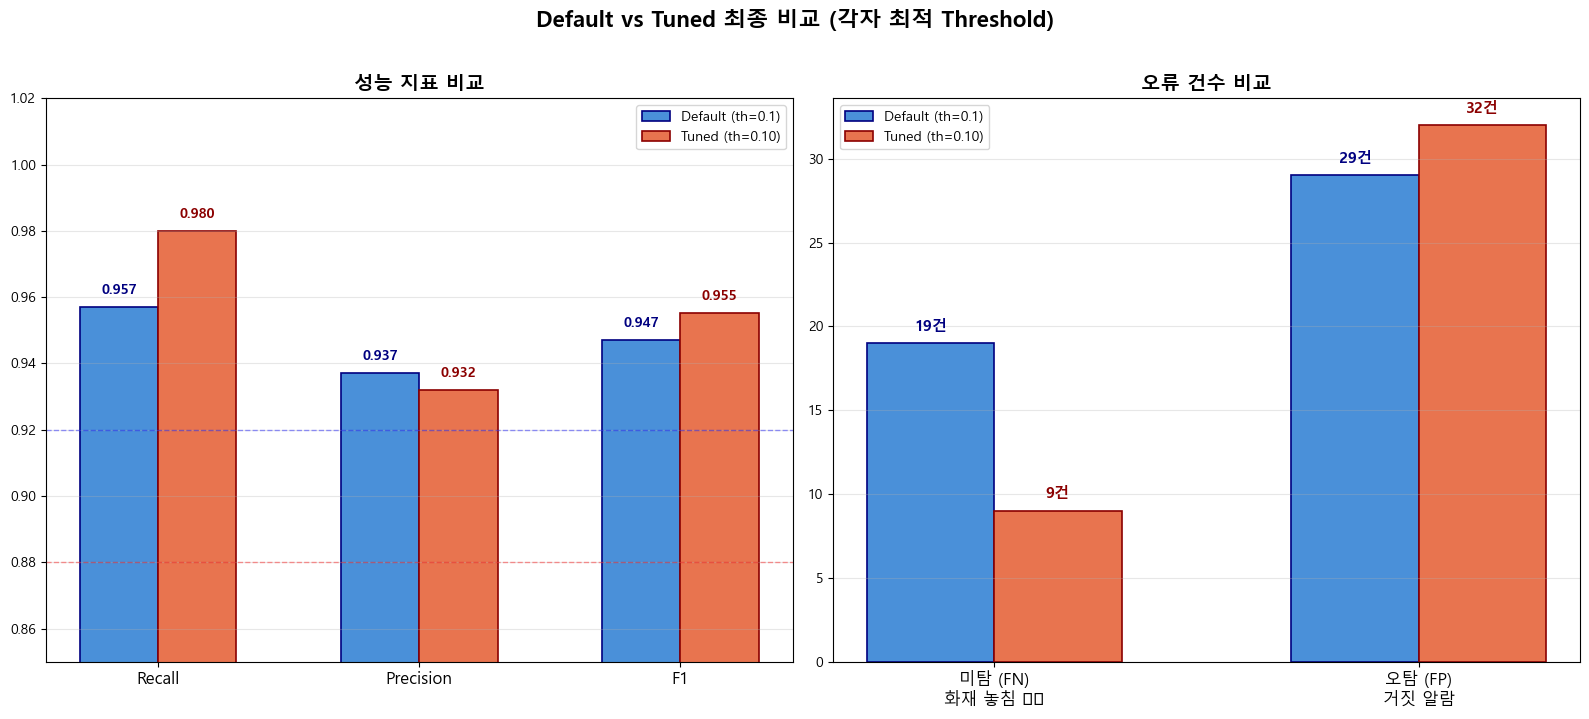

💾 그래프 저장: N:\개인\이수빈\3.13_Mini_Project\evaluation\yolov8n_tuned_threshold\default_vs_tuned_comparison.png


In [13]:
# =============================================================================
# [셀 11] 시각화 3: Default vs Tuned 최종 비교 막대그래프
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── 왼쪽: Recall / Precision / F1 비교 ──
ax1 = axes[0]
metrics = ['Recall', 'Precision', 'F1']
default_vals = [default_best['recall'], default_best['precision'], default_best['f1']]
tuned_vals = [tuned_best['recall'], tuned_best['precision'], tuned_best['f1']]

x = range(len(metrics))
width = 0.3

bars1 = ax1.bar([i - width/2 for i in x], default_vals, width,
                label=f"Default (th={default_best['threshold']})",
                color='#4A90D9', edgecolor='navy', linewidth=1.2)
bars2 = ax1.bar([i + width/2 for i in x], tuned_vals, width,
                label=f"Tuned (th={tuned_best['threshold']:.2f})",
                color='#E8744F', edgecolor='darkred', linewidth=1.2)

# 수치 표시
for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., h + 0.003,
             f'{h:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='navy')
for bar in bars2:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., h + 0.003,
             f'{h:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='darkred')

# KPI 목표선
ax1.axhline(y=KPI_RECALL, color='blue', linestyle='--', alpha=0.4, linewidth=1)
ax1.axhline(y=KPI_PRECISION, color='red', linestyle='--', alpha=0.4, linewidth=1)

ax1.set_title('성능 지표 비교', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, fontsize=12)
ax1.set_ylim(0.85, 1.02)
ax1.legend(fontsize=10)
ax1.grid(True, axis='y', alpha=0.3)

# ── 오른쪽: 미탐/오탐 비교 ──
ax2 = axes[1]
error_types = ['미탐 (FN)\n화재 놓침 ⚠️', '오탐 (FP)\n거짓 알람']
default_errors = [default_best['fn'], default_best['fp']]
tuned_errors = [int(tuned_best['fn']), int(tuned_best['fp'])]

x2 = range(len(error_types))
bars3 = ax2.bar([i - width/2 for i in x2], default_errors, width,
                label=f"Default (th={default_best['threshold']})",
                color='#4A90D9', edgecolor='navy', linewidth=1.2)
bars4 = ax2.bar([i + width/2 for i in x2], tuned_errors, width,
                label=f"Tuned (th={tuned_best['threshold']:.2f})",
                color='#E8744F', edgecolor='darkred', linewidth=1.2)

# 건수 표시
for bar in bars3:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., h + 0.5,
             f'{int(h)}건', ha='center', va='bottom', fontsize=11, fontweight='bold', color='navy')
for bar in bars4:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., h + 0.5,
             f'{int(h)}건', ha='center', va='bottom', fontsize=11, fontweight='bold', color='darkred')

ax2.set_title('오류 건수 비교', fontsize=14, fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(error_types, fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, axis='y', alpha=0.3)

# 전체 제목
fig.suptitle('Default vs Tuned 최종 비교 (각자 최적 Threshold)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
chart_path3 = EVAL_DIR / 'default_vs_tuned_comparison.png'
plt.savefig(chart_path3, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 그래프 저장: {chart_path3}")


## 셀 12: 전체 결과 JSON 저장


In [14]:
# =============================================================================
# [셀 12] 전체 결과를 JSON으로 저장
# =============================================================================

save_data = {
    "model": "YOLOv8n_tuned",
    "evaluation_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "thresholds_tested": THRESHOLDS,
    "results": all_results,
    "best_threshold": {
        "threshold": tuned_best['threshold'],
        "recall": tuned_best['recall'],
        "precision": tuned_best['precision'],
        "f1": tuned_best['f1'],
        "fn": int(tuned_best['fn']),
        "fp": int(tuned_best['fp'])
    },
    "comparison_with_default": {
        "default_threshold": default_best['threshold'],
        "default_recall": default_best['recall'],
        "default_precision": default_best['precision'],
        "default_f1": default_best['f1'],
        "winner": "tuned" if tuned_best['f1'] >= default_best['f1'] else "default"
    }
}

json_path = EVAL_DIR / 'threshold_optimization_results.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(save_data, f, indent=2, ensure_ascii=False)
print(f"💾 전체 결과 저장: {json_path}")

# CSV로도 저장 (비교표를 엑셀에서 보기 위해)
csv_path = EVAL_DIR / 'threshold_comparison_table.csv'
df.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"💾 비교표 CSV: {csv_path}")

print("\n✅ 모든 결과 저장 완료!")


💾 전체 결과 저장: N:\개인\이수빈\3.13_Mini_Project\evaluation\yolov8n_tuned_threshold\threshold_optimization_results.json
💾 비교표 CSV: N:\개인\이수빈\3.13_Mini_Project\evaluation\yolov8n_tuned_threshold\threshold_comparison_table.csv

✅ 모든 결과 저장 완료!
